## Part A: Support Vector Machine (SVM)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA

1. Load the dataset and perform the necessary preprocessing.

In [2]:
df = pd.read_csv("wdbc.data", header = None, names = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)])

print(df.head())

         id diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  ...  feature_21  feature_22  feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   feature_24  feature_25  feature_26  featu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    str    
 2   feature_1   569 non-null    float64
 3   feature_2   569 non-null    float64
 4   feature_3   569 non-null    float64
 5   feature_4   569 non-null    float64
 6   feature_5   569 non-null    float64
 7   feature_6   569 non-null    float64
 8   feature_7   569 non-null    float64
 9   feature_8   569 non-null    float64
 10  feature_9   569 non-null    float64
 11  feature_10  569 non-null    float64
 12  feature_11  569 non-null    float64
 13  feature_12  569 non-null    float64
 14  feature_13  569 non-null    float64
 15  feature_14  569 non-null    float64
 16  feature_15  569 non-null    float64
 17  feature_16  569 non-null    float64
 18  feature_17  569 non-null    float64
 19  feature_18  569 non-null    float64
 20 

In [4]:
df.shape

(569, 32)

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df = df.drop("id", axis = 1)

# Encoding the target variable
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis = 1)
y = df["diagnosis"]

print("Features:", X.shape)
print("Target:", y.shape)
print(y.value_counts())

Features: (569, 30)
Target: (569,)
diagnosis
0    357
1    212
Name: count, dtype: int64


2. Split the dataset into training and testing sets (80:20).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


3. Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.

In [8]:
pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel = "linear"))])

param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = "accuracy")

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'svm__C': 0.1}
Best Cross-Validation Accuracy: 0.9692307692307693


In [9]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

4. Evaluate the model using:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix


In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


In [11]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [12]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9523809523809523


In [13]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.975609756097561


In [14]:
print("Model Evaluation")
print(" ")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")

Model Evaluation
 
Accuracy :  0.9825
Precision:  1.0000
Recall   :  0.9524
F1 Score :  0.9756


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 2 40]]


5. Summarize your observations.

- The best hyperparameter was C = 0.1, with a cross-validation accuracy of 96.92%. This indicates that a relatively smaller value of C provided the best generalization performance for the Linear SVM.
- The Linear SVM achieved a test accuracy of 98.25%, meaning that 98.25% of the test samples were classified correctly.
- The precision was 100%, indicating that all samples predicted as malignant were actually malignant. There were no false positives.
- The recall was 95.24%, meaning that the model correctly identified 95.24% of the actual malignant cases. Out of 42 malignant cases, 40 were correctly identified and 2 were misclassified as benign.
- The F1 score of 97.56% indicates an excellent balance between precision and recall.

- True Negatives (TN) = 72
- False Positives (FP) = 0
- False Negatives (FN) = 2
- True Positives (TP) = 40

Overall, the Linear SVM performed very well on the Breast Cancer Wisconsin Diagnostic dataset. The high accuracy and F1 score demonstrate strong classification performance. However, the two false negatives are important because, in a medical diagnosis context, incorrectly classifying a malignant tumor as benign can be more serious than a false positive.

## Part B: Principal Component Analysis (PCA)

1. Load the dataset and perform feature standardization.

In [17]:
wine = pd.read_csv("wine.data", header = None)

wine.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [18]:
columns = ["Class", "Alcohol", "Malic_Acid", "Ash", "Alcalinity_of_Ash", "Magnesium", "Total_Phenols", "Flavanoids", "Nonflavanoid_Phenols", "Proanthocyanins", "Color_Intensity", "Hue", "OD280_OD315", "Proline"]

In [19]:
wine.columns = columns

print(wine.head())
print("Dataset Shape:", wine.shape)

   Class  Alcohol  Malic_Acid   Ash  Alcalinity_of_Ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_Phenols  Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_Intensity   Hue  OD280_OD315  Proline  
0             5.64  1.04         3.92     1065  
1             4.38  1.05         3.40     1050  
2          

In [20]:
X = wine.drop("Class", axis = 1)
y = wine["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (178, 13)
Target: (178,)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized Data:")
print(X_scaled[:5])

Standardized Data:
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


2. Apply PCA to reduce the dataset from 13 features to 2 principal components.

In [24]:
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (178, 13)
Transformed shape: (178, 2)


3. Display the explained variance ratio of each principal component.

In [25]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.36198848 0.1920749 ]


In [26]:
print("Total variance explained by 2 PCs:",
      pca.explained_variance_ratio_.sum())

Total variance explained by 2 PCs: 0.5540633835693527


4. Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

In [27]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative Explained Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [29]:
for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance), start = 1
):
    print(
        f"PC{i}: "
        f"Explained = {individual:.4f}, "
        f"Cumulative = {cumulative:.4f}"
    )

PC1: Explained = 0.3620, Cumulative = 0.3620
PC2: Explained = 0.1921, Cumulative = 0.5541
PC3: Explained = 0.1112, Cumulative = 0.6653
PC4: Explained = 0.0707, Cumulative = 0.7360
PC5: Explained = 0.0656, Cumulative = 0.8016
PC6: Explained = 0.0494, Cumulative = 0.8510
PC7: Explained = 0.0424, Cumulative = 0.8934
PC8: Explained = 0.0268, Cumulative = 0.9202
PC9: Explained = 0.0222, Cumulative = 0.9424
PC10: Explained = 0.0193, Cumulative = 0.9617
PC11: Explained = 0.0174, Cumulative = 0.9791
PC12: Explained = 0.0130, Cumulative = 0.9920
PC13: Explained = 0.0080, Cumulative = 1.0000


In [31]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Minimum number of components required for 95% variance:",
    n_components_95
)

Minimum number of components required for 95% variance: 10


5. Visualize the transformed dataset using a two dimensional scatter plot.

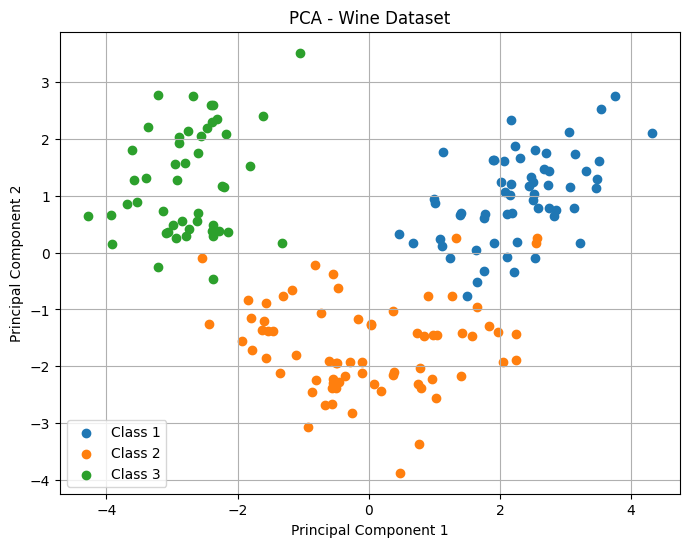

In [34]:
plt.figure(figsize = (8, 6))

for wine_class in sorted(y.unique()):
    plt.scatter(
        X_pca[y == wine_class, 0],
        X_pca[y == wine_class, 1],
        label = f"Class {wine_class}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Wine Dataset")
plt.legend()
plt.grid()
plt.show()

6. Compare the original and transformed datasets in terms of:
- Number of features
- Information retained
- Computational efficiency

| Aspect | Original Dataset | PCA Dataset (2 PCs) |
|---|---|---|
| Number of features | 13 | 2 |
| Information retained | 100% | ≈ 55.37% |
| Dimensionality | High | Low |
| Computational cost | Higher | Lower |
| Visualization | Difficult in 13 dimensions | Easy in 2 dimensions |
| Feature interpretability | Original features have direct meaning | PCs are combinations of original features |

7. Interpret the significance of the first two principal components.

In [35]:
loadings = pd.DataFrame(pca.components_.T, index = X.columns, columns = ["PC1", "PC2"])
print(loadings)

                           PC1       PC2
Alcohol               0.144329  0.483652
Malic_Acid           -0.245188  0.224931
Ash                  -0.002051  0.316069
Alcalinity_of_Ash    -0.239320 -0.010591
Magnesium             0.141992  0.299634
Total_Phenols         0.394661  0.065040
Flavanoids            0.422934 -0.003360
Nonflavanoid_Phenols -0.298533  0.028779
Proanthocyanins       0.313429  0.039302
Color_Intensity      -0.088617  0.529996
Hue                   0.296715 -0.279235
OD280_OD315           0.376167 -0.164496
Proline               0.286752  0.364903


In [36]:
print("PC1 Contributions:")
print(loadings["PC1"].abs().sort_values(ascending = False))

print("PC2 Contributions:")
print(loadings["PC2"].abs().sort_values(ascending = False))

PC1 Contributions:
Flavanoids              0.422934
Total_Phenols           0.394661
OD280_OD315             0.376167
Proanthocyanins         0.313429
Nonflavanoid_Phenols    0.298533
Hue                     0.296715
Proline                 0.286752
Malic_Acid              0.245188
Alcalinity_of_Ash       0.239320
Alcohol                 0.144329
Magnesium               0.141992
Color_Intensity         0.088617
Ash                     0.002051
Name: PC1, dtype: float64
PC2 Contributions:
Color_Intensity         0.529996
Alcohol                 0.483652
Proline                 0.364903
Ash                     0.316069
Magnesium               0.299634
Hue                     0.279235
Malic_Acid              0.224931
OD280_OD315             0.164496
Total_Phenols           0.065040
Proanthocyanins         0.039302
Nonflavanoid_Phenols    0.028779
Alcalinity_of_Ash       0.010591
Flavanoids              0.003360
Name: PC2, dtype: float64


8. Discuss the advantages, limitations, and applications of PCA in machine learning.

Advantages:
- Dimensionality reduction
- Faster ML
- Visualization
- Reduces noise


Limitation:
- Loss of info
- Reduced interpretability
- Sensitive to scaling


Applications
- Data visualization
- Feature reduction
- Image processing
- EDA
- Preprocessing for ML models 